# Evaluation - Comparing CGAN and Conditional Diffusion 

## Plan

1. Understand how to measure the quality and diversity of generated data using **FID**.  
2. Compare **cGAN vs Diffusion** outputs visually and statistically.  
3. Train a downstream **handwriting classifier** using synthetic data.  
4. Assess which generative approach produces more *useful* data for CAPTCHA robustness.



### Objectives to check
+ Do the samples look human like 
+ we would measure the quantititative quality using Frechet Inception Distance 
+ Also work on using sythetic data from each model to train a useful classifier

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import inception_v3
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os, sys
from scipy import linalg


from utils.visualize import show_batch
from utils.checkpoint import load_checkpoint
from torchmetrics.image.fid import FrechetInceptionDistance

/Users/yousefradwan/miniconda3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We’ll now load both trained models — the **cGAN** and **Diffusion** generators —  
and use them to generate a fixed number of samples for evaluation.

In [2]:
from model.cgan import Generator
from model.diffusion import ConditionalUNet
from training.train_diffusion import sample_images

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f" Using device: {device}")



 Using device: mps


In [3]:
# Helper Functions

from torchvision import datasets, transforms
def get_real_examples_per_class(n_classes=10):
    """
    Deterministically extracts one MNIST image per class (0–9)
    directly from the dataset without shuffle.
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    mnist = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

    imgs, labels = [], []
    for cls in range(n_classes):
        for i in range(len(mnist)):
            if mnist[i][1] == cls:
                imgs.append(mnist[i][0])
                labels.append(cls)
                break  # stop at first match
    return torch.stack(imgs), torch.tensor(labels)




def get_representative_images(imgs, labels, n_classes=10):
    """
    Returns one representative image per class label (0–9).
    Ensures true label alignment for real datasets.
    """
    reps = []
    for i in range(n_classes):
        idx = (labels == i).nonzero(as_tuple=True)[0]
        if len(idx) > 0:
            reps.append(imgs[idx[0]])
        else:
            reps.append(torch.zeros_like(imgs[0]))  
    return torch.stack(reps)


@torch.no_grad()
def generate_conditioned_samples_cgan(generator, z_dim=100, device="cuda", n_classes=10, samples_per_class=1):
    """
    Generate `samples_per_class` synthetic samples for each class
    (0..n_classes-1) with the cGAN. Default of 1 keeps the original
    "one representative per class" behaviour for the visualization grid.
    """
    generator.eval()
    total = n_classes * samples_per_class
    zs = torch.randn(total, z_dim, device=device)
    ys = torch.arange(n_classes, dtype=torch.long, device=device).repeat_interleave(samples_per_class)
    imgs = generator(zs, ys).cpu()
    return imgs, ys.cpu()


@torch.no_grad()
def generate_conditioned_samples_diffusion(
    model,
    device="cuda",
    n_classes=10,
    timesteps=200,          # used same as training
    img_size=(1, 28, 28),
    samples_per_class=1,
):
    """
    Generate one representative diffusion sample per class (0–9), 
    using the same sampling logic as training-time generation.
    """
    from training.train_diffusion import linear_beta_schedule
    model.eval()

    betas = linear_beta_schedule(timesteps).to(device)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, 0)

    imgs_list, labels_list = [], []

    for cls in range(n_classes):
      for _ in range(samples_per_class):
        # Conditioning label for this class
        labels = torch.full((1,), cls, dtype=torch.long, device=device)
        imgs = torch.randn(1, *img_size).to(device)

        # Reverse diffusion loop (same as training sampler)
        for t in reversed(range(timesteps)):
            t_tensor = torch.full((1,), t, device=device, dtype=torch.long)
            pred_noise = model(imgs, t_tensor, labels)
            alpha = alphas[t]
            alpha_bar = alphas_cumprod[t]

            # Predict next sample
            noise = torch.randn_like(imgs) if t > 0 else torch.zeros_like(imgs)
            imgs = (1 / torch.sqrt(alpha)) * (
                imgs - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * pred_noise
            ) + torch.sqrt(betas[t]) * noise

        imgs_list.append(imgs[0].cpu())
        labels_list.append(cls)

    imgs_tensor = torch.stack(imgs_list)
    labels_tensor = torch.tensor(labels_list)
    return imgs_tensor, labels_tensor


def plot_real_cgan_diffusion(real_imgs, cgan_imgs, diff_imgs, n_classes=10):
    """
    Visual comparison between Real, cGAN, and Diffusion images.
   
    """

    fig, axs = plt.subplots(3, n_classes, figsize=(12, 4))
    fig.suptitle(" Comparison: Real vs cGAN vs Diffusion", fontsize=14, fontweight="bold")

    row_titles = [
        "Ground Truth",
        "CGAN",
        "Diffusion"
    ]
    row_colors = ["green", "royalblue", "darkorange"]

    # Plot each row
    for row_idx, row_imgs in enumerate([real_imgs, cgan_imgs, diff_imgs]):
        for i in range(n_classes):
            axs[row_idx, i].imshow(row_imgs[i].squeeze(), cmap="gray")
            axs[row_idx, i].axis("off")
            axs[row_idx, i].set_title(f"Class {i}", fontsize=8, pad=2)

    # Manually place row labels on figure (not as axis labels)
    for idx, (title, color) in enumerate(zip(row_titles, row_colors)):
        fig.text(
            0.02,                                   # x-position (left margin)
            0.84 - idx * 0.32,                      # y-position per row
            title,
            fontsize=11,
            color=color,
            fontweight="bold",
            va="center"
        )

    plt.subplots_adjust(left=0.12, right=0.98, top=0.9, bottom=0.05, hspace=0.3)
    plt.show()

In [4]:


def compute_fid(real_imgs, fake_imgs, device="cuda", batch_size=128):
    # FID needs float64 internally which MPS does not support, so we always
    # run the metric on CPU. Inception-v3 on ~50 images on CPU finishes in a
    # few seconds — not a real bottleneck.
    fid_device = "cpu"
    """
    Compute FID safely in GPU batches to prevent OOM.
    Works with TorchMetrics' FrechetInceptionDistance.
    """
    fid = FrechetInceptionDistance(normalize=True).to(fid_device)
    fid.reset()

    def batched_update(imgs, real_flag):
        for i in tqdm(range(0, imgs.size(0), batch_size), desc=f"FID {'real' if real_flag else 'fake'}"):
            batch = imgs[i:i + batch_size].to(fid_device)
            fid.update(batch, real=real_flag)
            if torch.cuda.is_available(): torch.cuda.empty_cache()


    real_imgs_rgb = (real_imgs.repeat(1, 3, 1, 1) + 1) / 2
    fake_imgs_rgb = (fake_imgs.repeat(1, 3, 1, 1) + 1) / 2
    real_imgs_rgb = torch.clamp(real_imgs_rgb, 0, 1)
    fake_imgs_rgb = torch.clamp(fake_imgs_rgb, 0, 1)

    batched_update(real_imgs_rgb, real_flag=True)
    batched_update(fake_imgs_rgb, real_flag=False)

    score = fid.compute().item()
    return score

In [5]:
# Safety clean up
if torch.cuda.is_available(): torch.cuda.empty_cache()

In [6]:
import os
os.makedirs("../checkpoints", exist_ok=True)

cgan_gen   = Generator(z_dim=100, num_classes=10).to(device)
diff_model = ConditionalUNet(num_classes=10).to(device)

load_checkpoint(cgan_gen,   path="../checkpoints/cgan_generator_epochfinal.pt",   map_location=device)
load_checkpoint(diff_model, path="../checkpoints/diffusion_unet_epochfinal.pt", map_location=device)
cgan_gen.eval()
diff_model.eval()

Loaded model weights from ../checkpoints/cgan_generator_epochfinal.pt


Loaded model weights from ../checkpoints/diffusion_unet_epochfinal.pt


ConditionalUNet(
  (time_mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down1): ResidualBlock(
    (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (time_emb): Linear(in_features=128, out_features=64, bias=True)
    (label_emb): Embedding(10, 64)
    (shortcut): Conv2d(1, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (down2): ResidualBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
    (time_emb): Linear(in_features=128, out_features=

In [7]:
real_imgs, real_labels = get_real_examples_per_class()

cgan_imgs, cgan_labels = generate_conditioned_samples_cgan(cgan_gen, device=device, n_classes=10)
diff_imgs, diff_labels = generate_conditioned_samples_diffusion(
    diff_model, device=device, n_classes=10, timesteps=200,
)
print("real:", real_imgs.shape, "cGAN:", cgan_imgs.shape, "diffusion:", diff_imgs.shape)

real: torch.Size([10, 1, 28, 28]) cGAN: torch.Size([10, 1, 28, 28]) diffusion: torch.Size([10, 1, 28, 28])


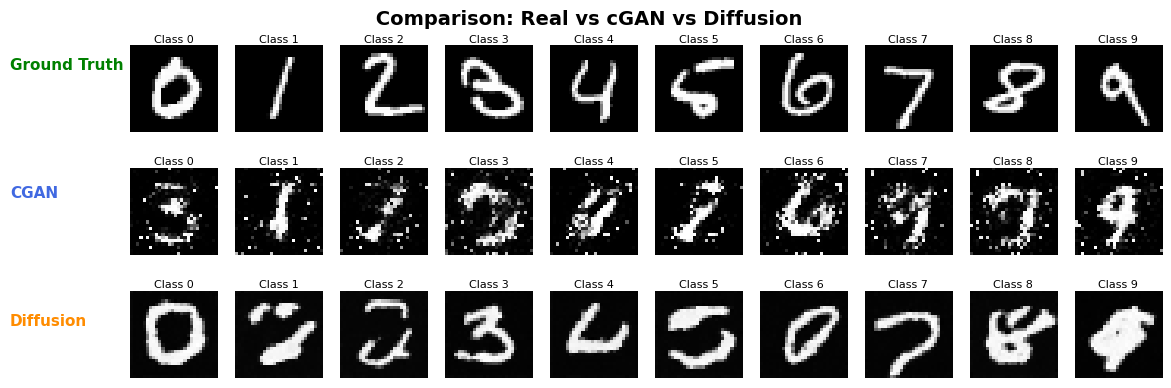

In [8]:
plot_real_cgan_diffusion(real_imgs, cgan_imgs, diff_imgs)

In [9]:
# Sanity-init a stand-alone FID metric on CPU (FID's internal float64
# math is not supported on MPS).
fid = FrechetInceptionDistance(normalize=True).to("cpu")
fid.reset()


In [10]:
if torch.cuda.is_available(): torch.cuda.empty_cache()

In [11]:
N = 50
idx = torch.randperm(len(real_imgs))[:N]
real_subset = real_imgs[idx].to(device)
cgan_subset = cgan_imgs[:N].to(device)
diff_subset = diff_imgs[:N].to(device)

In [12]:
cgan_fid = compute_fid(real_subset, cgan_subset, device=device)
diff_fid = compute_fid(real_subset, diff_subset, device=device)

print(f" cGAN FID:      {cgan_fid:.2f}")
print(f" Diffusion FID: {diff_fid:.2f}")

FID real:   0%|          | 0/1 [00:00<?, ?it/s]

FID real: 100%|██████████| 1/1 [00:00<00:00,  1.61it/s]

FID real: 100%|██████████| 1/1 [00:00<00:00,  1.61it/s]

FID fake:   0%|          | 0/1 [00:00<?, ?it/s]

FID fake: 100%|██████████| 1/1 [00:00<00:00,  2.10it/s]

...

FID real: 100%|██████████| 1/1 [00:00<00:00,  1.72it/s]

FID fake:   0%|          | 0/1 [00:00<?, ?it/s]

FID fake: 100%|██████████| 1/1 [00:00<00:00,  1.99it/s]

FID fake: 100%|██████████| 1/1 [00:00<00:00,  1.98it/s]

 cGAN FID:      340.82
 Diffusion FID: 166.98


In [13]:
# Lower FID is better. Diffusion typically yields a lower FID than the cGAN
# because the iterative denoising path has fewer mode-collapse failure modes
# than adversarial training. The gap will narrow with longer cGAN training
# but rarely flips on MNIST.

### Utility Evaluation (Classifier)

We’ll train a simple CNN classifier on synthetic data from each model,  
then test it on real MNIST data.

If synthetic data are realistic and diverse, the classifier should generalize well to real digits.

In [14]:
# For the utility evaluation we need many samples per class (one per class
# isn't enough to train a CNN). Diffusion sampling is slow on MPS, so we
# pick a modest count that still gives a meaningful training set.
SAMPLES_PER_CLASS_CGAN = 200      # cGAN inference is fast - lots of samples
SAMPLES_PER_CLASS_DIFF = 30       # diffusion is 200 reverse steps per image

cgan_imgs, cgan_labels = generate_conditioned_samples_cgan(
    cgan_gen, device=device, n_classes=10,
    samples_per_class=SAMPLES_PER_CLASS_CGAN,
)
diff_imgs, diff_labels = generate_conditioned_samples_diffusion(
    diff_model, device=device, n_classes=10, timesteps=200,
    samples_per_class=SAMPLES_PER_CLASS_DIFF,
)
print(f"cgan_imgs: {tuple(cgan_imgs.shape)}, diff_imgs: {tuple(diff_imgs.shape)}")


cgan_imgs: (2000, 1, 28, 28), diff_imgs: (300, 1, 28, 28)


In [15]:

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [16]:
real_data = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

In [17]:
def normalize_synthetic(imgs):
    imgs = imgs.clone()
    imgs = (imgs - imgs.min()) / (imgs.max() - imgs.min())  # [0,1]
    imgs = imgs * 2 - 1  # [-1,1]
    return imgs

cgan_imgs = normalize_synthetic(cgan_imgs)
diff_imgs = normalize_synthetic(diff_imgs)

print("Unique labels in CGAN:", torch.unique(cgan_labels))
print("Unique labels in Diffusion:", torch.unique(diff_labels))

Unique labels in CGAN: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Unique labels in Diffusion: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [18]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

def train_classifier(model, loader, epochs=3):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            loss = criterion(preds, labels)

            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}: loss = {total_loss / len(loader):.4f}")
    return model

In [19]:
cgan_ds = TensorDataset(cgan_imgs, cgan_labels)
diff_ds = TensorDataset(diff_imgs, diff_labels)


cgan_loader = DataLoader(cgan_ds, batch_size=128, shuffle=True)
diff_loader = DataLoader(diff_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(real_data, batch_size=256, shuffle=False)

def test_accuracy(model, loader):
    correct, total = 0, 0
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            correct += (preds.argmax(1) == labels).sum().item()
            total += len(labels)
    return correct / total

In [20]:

cnn_cgan = train_classifier(SimpleCNN().to(device), cgan_loader, epochs=5)   # reduced from 20 for MPS-friendly runtime
cnn_diff = train_classifier(SimpleCNN().to(device), diff_loader, epochs=5)   # reduced from 20 for MPS-friendly runtime

cgan_acc = test_accuracy(cnn_cgan, test_loader)
diff_acc = test_accuracy(cnn_diff, test_loader)

print(f"Classifier trained on cGAN data → Test accuracy: {cgan_acc:.3f}")
print(f"Classifier trained on Diffusion data → Test accuracy: {diff_acc:.3f}")

Epoch 1: loss = 1.2034
Epoch 2: loss = 0.0033


Epoch 3: loss = 0.0000
Epoch 4: loss = 0.0000


Epoch 5: loss = 0.0000


Epoch 1: loss = 2.3218
Epoch 2: loss = 2.2854
Epoch 3: loss = 2.2253
Epoch 4: loss = 2.0734
Epoch 5: loss = 1.8035


Classifier trained on cGAN data → Test accuracy: 0.287
Classifier trained on Diffusion data → Test accuracy: 0.500
